Student Name : Eaint Taryar Linlat

# Task 18 — Synthetic Fraud Transaction Data Generation & Quality Evaluation
---

## Objective

Generate **5,000 synthetic records** from `fraud_transactions.csv` using two
generative models — **CTGAN** and **TVAE** — and rigorously evaluate the
quality of each synthetic dataset across three pillars:

| Pillar | Question | Method |
|--------|----------|--------|
| **Fidelity** | Does synthetic data look statistically like real data? | KS test, categorical frequency comparison, correlation matrices |
| **Utility** | Can a model trained on synthetic data work on real data? | Train-Synthetic-Test-Real (TSTR) vs TRTR baseline |
| **Privacy** | Did either model memorise real records? | Nearest-Neighbour Distance heuristic |

---

### Why Two Models?

- **CTGAN** uses adversarial training (generator vs discriminator) with
  mode-specific normalisation designed for imbalanced tabular data.
- **TVAE** uses a variational autoencoder (encoder → latent space → decoder)
  with a KL-divergence regularisation term.

Both handle mixed categorical/numeric data, but they learn the data distribution
differently. Comparing them reveals the fidelity–utility–privacy trade-off.

---

## Section 0 — Install Dependencies

| Package | Purpose |
|---------|--------|
| `sdv` | TVAESynthesizer + SingleTableMetadata |
| `ctgan` | CTGAN model |
| `scikit-learn` | Preprocessing, Random Forest, AUC/F1 |
| `scipy` | KS two-sample test |
| `matplotlib` / `seaborn` | Visualisations |

In [ ]:
!pip install -q sdv ctgan
print('All dependencies installed.')

All dependencies installed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from scipy.stats import ks_2samp
from sklearn.neighbors import NearestNeighbors

print('Libraries loaded.')

Libraries loaded.


## Section 1 — Load and Inspect `fraud_transactions.csv`

We begin with a thorough inspection to understand:
- Column types and cardinality (crucial for deciding what to drop)
- The class balance of `is_fraud` (expected ~7-8% fraud rate)
- Numeric distributions that synthesisers will need to replicate

In [ ]:
df_raw = pd.read_csv('/content/fraud_transactions.csv')

print(f'Shape  : {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Shape  : (6486, 8)
Columns: ['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'state', 'job', 'is_fraud']


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2/27/19 21:32,"fraud_Langosh, Wintheiser and Hyatt",food_dining,83.64,F,TX,"Physicist, medical",0
1,2/13/19 19:41,fraud_Dibbert and Sons,entertainment,79.13,M,PA,Secretary/administrator,0
2,1/11/19 20:03,"fraud_McDermott, Osinski and Morar",home,12.02,F,CA,"Buyer, industrial",0
3,1/20/19 9:08,fraud_Bauch-Raynor,grocery_pos,84.41,M,TN,Clothing/textile technologist,0
4,1/4/19 17:04,"fraud_Reichert, Huels and Hoppe",shopping_net,2.81,F,ME,Financial trader,0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  6486 non-null   object 
 1   merchant               6486 non-null   object 
 2   category               6486 non-null   object 
 3   amt                    6486 non-null   float64
 4   gender                 6486 non-null   object 
 5   state                  6486 non-null   object 
 6   job                    6486 non-null   object 
 7   is_fraud               6486 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 405.5+ KB


In [ ]:
print('Numeric summary:')
display(df_raw.describe())

print('\nUnique values per column (key for cardinality decisions):')
print(df_raw.nunique().sort_values(ascending=False))

Numeric summary:


,amt,is_fraud
count,6486.000000,6486.000000
mean,101.700956,0.074931
std,189.292632,0.263300
min,1.000000,0.000000
25%,12.572500,0.000000
50%,52.080000,0.000000
75%,91.945000,0.000000
max,2312.210000,1.000000



Unique values per column (key for cardinality decisions):
trans_date_trans_time    6191
amt                      5037
merchant                  692
job                       472
state                      50
category                   14
gender                      2
is_fraud                    2
dtype: int64


Target class distribution (is_fraud):
is_fraud
0    0.925069
1    0.074931
Name: proportion, dtype: float64


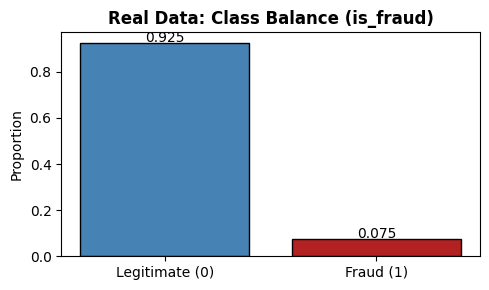

In [ ]:
print('Target class distribution (is_fraud):')
fraud_dist = df_raw['is_fraud'].value_counts(normalize=True)
print(fraud_dist)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Legitimate (0)', 'Fraud (1)'],
       [fraud_dist.get(0, 0), fraud_dist.get(1, 0)],
       color=['steelblue', 'firebrick'], edgecolor='black')
ax.set_title('Real Data: Class Balance (is_fraud)', fontweight='bold')
ax.set_ylabel('Proportion')
for i, v in enumerate([fraud_dist.get(0,0), fraud_dist.get(1,0)]):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_balance_real.png', dpi=120)
plt.show()

## Section 2 — Preprocessing

### Column selection rationale

We drop columns that are unsuitable for tabular synthesis:

| Dropped Column | Reason |
|---------------|--------|
| `trans_date_trans_time` | Raw timestamp string — not directly generatable |
| `merchant` | Very high cardinality (600+ unique values) — GANs collapse on these |
| `job` | Very high cardinality (400+ unique values) — same issue |

We keep:
- **Categorical:** `category` (14 values), `gender` (2), `state` (50)
- **Numeric:** `amt` (transaction amount — the key financial signal)
- **Target:** `is_fraud` (binary, ~7-8% positive rate)

In [ ]:
TARGET_COL = 'is_fraud'
DROP_COLS  = ['trans_date_trans_time', 'merchant', 'job']
CAT_COLS   = ['category', 'gender', 'state']
NUM_COLS   = ['amt']

df = df_raw.drop(columns=DROP_COLS, errors='ignore').copy()
df = df.dropna().reset_index(drop=True)

# Keep only the columns we need for synthesis
synth_cols = CAT_COLS + NUM_COLS + [TARGET_COL]
df = df[synth_cols].copy()

print(f'Working dataset shape : {df.shape}')
print(f'Categorical columns   : {CAT_COLS}')
print(f'Numeric columns       : {NUM_COLS}')
print(f'Target column         : {TARGET_COL}')
display(df.head())

Working dataset shape : (6486, 5)
Categorical columns   : ['category', 'gender', 'state']
Numeric columns       : ['amt']
Target column         : is_fraud


,category,gender,state,amt,is_fraud
0,food_dining,F,TX,83.64,0
1,entertainment,M,PA,79.13,0
2,home,F,CA,12.02,0
3,grocery_pos,M,TN,84.41,0
4,shopping_net,F,ME,2.81,0


In [ ]:
# Real/test split — stratified to preserve ~7-8% fraud rate in both sets
real_train, real_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET_COL]
)

print(f'Training set : {real_train.shape}')
print(f'Test set     : {real_test.shape}')
print(f'Fraud rate in train: {real_train[TARGET_COL].mean():.4f}')
print(f'Fraud rate in test : {real_test[TARGET_COL].mean():.4f}')

Training set : (5188, 5)
Test set     : (1298, 5)
Fraud rate in train: 0.0750
Fraud rate in test : 0.0747


## Section 3 — Train CTGAN and Generate 5,000 Synthetic Records

**CTGAN** (Conditional Tabular GAN) key innovations for tabular data:
- **Mode-specific normalisation** for numeric columns (handles multimodal distributions)
- **Training-by-sampling** to address imbalanced categorical distributions
- **Conditional generation** allowing us to condition on specific column values

We register `is_fraud` as a discrete column so CTGAN respects the binary constraint
and learns the fraud-rate distribution during training.

In [ ]:
from ctgan import CTGAN

DISCRETE_COLS = CAT_COLS + [TARGET_COL]   # binary target is also discrete
N_SYNTH       = 5_000

print(f'Training CTGAN (300 epochs, batch_size=500)...')
print(f'Discrete columns: {DISCRETE_COLS}')

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    verbose=True
)
ctgan.fit(df, discrete_columns=DISCRETE_COLS)

print('CTGAN training complete.')

Training CTGAN (300 epochs, batch_size=500)...
Discrete columns: ['category', 'gender', 'state', 'is_fraud']


Gen. (-00.31) | Discrim. (+00.02): 100%|██████████| 300/300 [06:03<00:00,  1.21s/it]

CTGAN training complete.


In [ ]:
synthetic_ctgan = ctgan.sample(N_SYNTH)

print(f'Generated {len(synthetic_ctgan)} CTGAN synthetic records')
print(f'Columns: {synthetic_ctgan.columns.tolist()}')
display(synthetic_ctgan.head())

Generated 5000 CTGAN synthetic records
Columns: ['category', 'gender', 'state', 'amt', 'is_fraud']


,category,gender,state,amt,is_fraud
0,gas_transport,M,WY,91.239334,0
1,misc_net,M,NC,12.686440,0
2,food_dining,F,TX,104.075114,0
3,personal_care,M,ND,3.503955,0
4,food_dining,F,NC,57.930709,0


In [ ]:
print('Class balance comparison (is_fraud):')
real_fraud_rate  = df[TARGET_COL].mean()
ctgan_fraud_rate = synthetic_ctgan[TARGET_COL].mean()

print(f'  Real data     : {real_fraud_rate:.4f} ({real_fraud_rate*100:.1f}% fraud)')
print(f'  CTGAN synthetic: {ctgan_fraud_rate:.4f} ({ctgan_fraud_rate*100:.1f}% fraud)')

Class balance comparison (is_fraud):
  Real data     : 0.0749 (7.5% fraud)
  CTGAN synthetic: 0.1444 (14.4% fraud)


## Section 4 — Train TVAE and Generate 5,000 Synthetic Records

**TVAE** (Tabular Variational Autoencoder) uses a different generative mechanism:
- **Encoder** compresses each row into a continuous latent vector
- **KL-divergence** regularises the latent space toward a standard normal prior
- **Decoder** reconstructs table rows from sampled latent vectors

The VAE approach tends to produce smoother interpolations in latent space,
which can improve fidelity for simple distributions but may over-smooth
complex multimodal ones.

In [ ]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

# Build SDV metadata — detect column types automatically, then override discrete cols
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

for col in DISCRETE_COLS:
    metadata.update_column(column_name=col, sdtype='categorical')

print('Training TVAE (300 epochs, batch_size=500)...')

tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=300,
    batch_size=500
)
tvae.fit(df)

print('TVAE training complete.')

Training TVAE (300 epochs, batch_size=500)...
TVAE training complete.


In [ ]:
synthetic_tvae = tvae.sample(N_SYNTH)

print(f'Generated {len(synthetic_tvae)} TVAE synthetic records')
tvae_fraud_rate = synthetic_tvae[TARGET_COL].mean()
print(f'  TVAE fraud rate: {tvae_fraud_rate:.4f} ({tvae_fraud_rate*100:.1f}% fraud)')
display(synthetic_tvae.head())

Generated 5000 TVAE synthetic records
  TVAE fraud rate: 0.0556 (5.6% fraud)


,category,gender,state,amt,is_fraud
0,entertainment,F,SC,19.19,0
1,shopping_pos,M,FL,23.29,0
2,entertainment,F,WA,43.28,0
3,grocery_pos,F,NY,100.15,0
4,shopping_net,M,NY,1.94,0


---
## Section 5 — Fidelity Evaluation

Fidelity measures how statistically similar the synthetic data is to the real data.
We evaluate three levels:

1. **Univariate numeric** — Kolmogorov-Smirnov (KS) test on `amt`
2. **Univariate categorical** — frequency distribution comparison
3. **Bivariate** — pairwise correlation matrix differences

Plus visualisations: `amt` distribution overlay and correlation heatmaps.

### 5.1 — Kolmogorov-Smirnov Test (Numeric Columns)

In [ ]:
def ks_per_feature(real_df, syn_df, cols):
    """KS two-sample test for each numeric column. Returns sorted DataFrame."""
    results = {}
    for col in cols:
        r = real_df[col].dropna().sample(min(5000, len(real_df)), random_state=42)
        s = syn_df[col].dropna().sample(min(5000, len(syn_df)),  random_state=42)
        stat, pval = ks_2samp(r, s)
        results[col] = {'ks_stat': round(stat, 4), 'p_value': round(pval, 6)}
    return pd.DataFrame(results).T

ks_ctgan = ks_per_feature(df, synthetic_ctgan, NUM_COLS)
ks_tvae  = ks_per_feature(df, synthetic_tvae,  NUM_COLS)

ks_compare = pd.DataFrame({
    'KS_CTGAN' : ks_ctgan['ks_stat'],
    'KS_TVAE'  : ks_tvae['ks_stat'],
}).sort_values('KS_CTGAN')

print('KS Statistics (lower = better fidelity):')
display(ks_compare)

winner_ks = 'CTGAN' if ks_compare['KS_CTGAN'].mean() < ks_compare['KS_TVAE'].mean() else 'TVAE'
print(f'Better numeric fidelity (avg KS): {winner_ks}')

KS Statistics (lower = better fidelity):


,KS_CTGAN,KS_TVAE
amt,0.07,0.033


Better numeric fidelity (avg KS): TVAE


### 5.2 — Transaction Amount (`amt`) Distribution Comparison

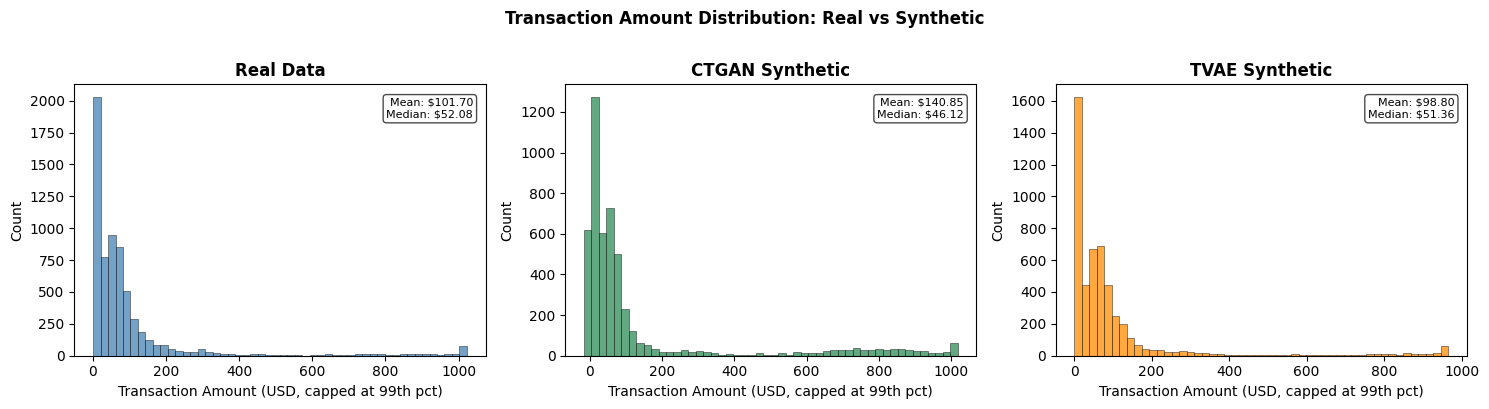

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

datasets = [
    (df['amt'],              'Real Data',       'steelblue'),
    (synthetic_ctgan['amt'], 'CTGAN Synthetic', 'seagreen'),
    (synthetic_tvae['amt'],  'TVAE Synthetic',  'darkorange'),
]

for ax, (data, label, color) in zip(axes, datasets):
    # Cap at 99th percentile for readability
    cap = data.quantile(0.99)
    ax.hist(data.clip(upper=cap), bins=50, color=color,
            alpha=0.75, edgecolor='black', linewidth=0.4)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Transaction Amount (USD, capped at 99th pct)')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'Mean: ${data.mean():.2f}\nMedian: ${data.median():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

fig.suptitle('Transaction Amount Distribution: Real vs Synthetic', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('amt_distribution_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.3 — Categorical Frequency Comparison

In [ ]:
def tvd(real_series, syn_series):
    """Total Variation Distance between two categorical distributions.
    TVD = 0.5 * sum(|p_real - p_syn|). Range [0,1]. Lower is better."""
    r = real_series.value_counts(normalize=True)
    s = syn_series.value_counts(normalize=True)
    all_cats = r.index.union(s.index)
    return 0.5 * (r.reindex(all_cats, fill_value=0) -
                  s.reindex(all_cats, fill_value=0)).abs().sum()

print('Categorical Frequency Comparison (TVD = Total Variation Distance)\n')
print(f'{'Column':<12} {'TVD_CTGAN':>12} {'TVD_TVAE':>12}')
print('-' * 40)

for col in CAT_COLS:
    tvd_c = tvd(df[col], synthetic_ctgan[col])
    tvd_t = tvd(df[col], synthetic_tvae[col])
    better = 'CTGAN' if tvd_c < tvd_t else 'TVAE '
    print(f'{col:<12} {tvd_c:>12.4f} {tvd_t:>12.4f}   <- {better} wins')

Categorical Frequency Comparison (TVD = Total Variation Distance)

Column          TVD_CTGAN     TVD_TVAE
----------------------------------------
category           0.1415       0.2408   <- CTGAN wins
gender             0.0293       0.0231   <- TVAE  wins
state              0.1285       0.2436   <- CTGAN wins


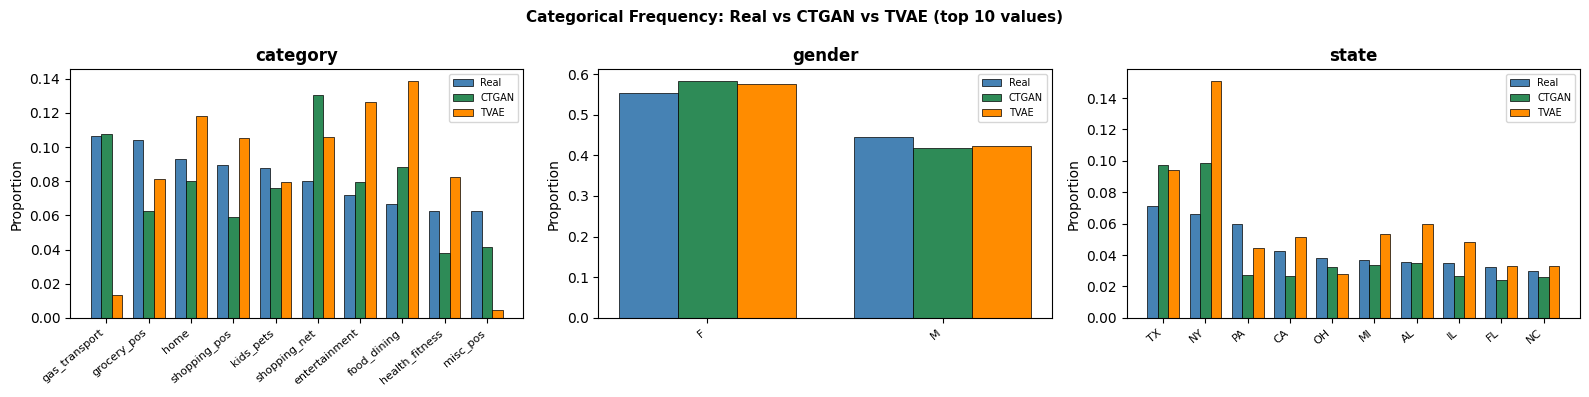

In [ ]:
# Visual: category frequency bars for top-level categories
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(16, 4))

for ax, col in zip(axes, CAT_COLS):
    r_freq = df[col].value_counts(normalize=True).head(10)
    c_freq = synthetic_ctgan[col].value_counts(normalize=True).reindex(r_freq.index, fill_value=0)
    t_freq = synthetic_tvae[col].value_counts(normalize=True).reindex(r_freq.index, fill_value=0)

    x = np.arange(len(r_freq))
    w = 0.25
    ax.bar(x - w, r_freq.values, w, label='Real',  color='steelblue', edgecolor='black', lw=0.5)
    ax.bar(x,     c_freq.values, w, label='CTGAN', color='seagreen',  edgecolor='black', lw=0.5)
    ax.bar(x + w, t_freq.values, w, label='TVAE',  color='darkorange',edgecolor='black', lw=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(r_freq.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=7)

fig.suptitle('Categorical Frequency: Real vs CTGAN vs TVAE (top 10 values)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_frequency_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.4 — Correlation Structure Comparison

In [ ]:
def encode_for_corr(dataframe):
    """Label-encode categoricals so we can compute a full correlation matrix."""
    tmp = dataframe.copy()
    for c in CAT_COLS:
        le = LabelEncoder()
        tmp[c] = le.fit_transform(tmp[c].astype(str))
    return tmp[CAT_COLS + NUM_COLS + [TARGET_COL]]

real_enc  = encode_for_corr(df)
ctgan_enc = encode_for_corr(synthetic_ctgan)
tvae_enc  = encode_for_corr(synthetic_tvae)

real_corr  = real_enc.corr()
ctgan_corr = ctgan_enc.corr()
tvae_corr  = tvae_enc.corr()

ctgan_diff = (real_corr - ctgan_corr).abs()
tvae_diff  = (real_corr - tvae_corr).abs()

corr_compare = pd.DataFrame({
    'mean_abs_diff_CTGAN': ctgan_diff.mean(),
    'mean_abs_diff_TVAE' : tvae_diff.mean()
}).sort_values('mean_abs_diff_CTGAN', ascending=False)

print('Mean Absolute Correlation Difference per Feature (lower = better):')
display(corr_compare)

Mean Absolute Correlation Difference per Feature (lower = better):


,mean_abs_diff_CTGAN,mean_abs_diff_TVAE
category,0.075403,0.028458
is_fraud,0.074435,0.012353
amt,0.053254,0.031125
state,0.029840,0.029371
gender,0.010685,0.019021


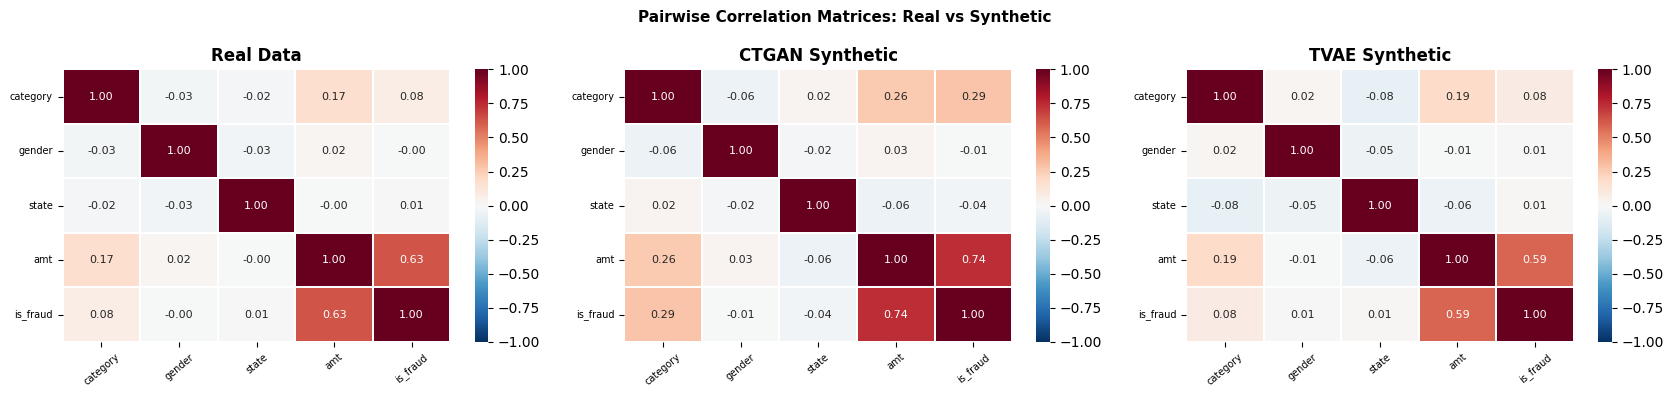

In [ ]:
# Heatmap of correlation matrices
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, corr_mat, title in zip(
        axes,
        [real_corr, ctgan_corr, tvae_corr],
        ['Real Data', 'CTGAN Synthetic', 'TVAE Synthetic']):
    sns.heatmap(
        corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
        center=0, vmin=-1, vmax=1, ax=ax,
        annot_kws={'size': 8}, linewidths=0.3
    )
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

fig.suptitle('Pairwise Correlation Matrices: Real vs Synthetic',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 6 — Utility Evaluation: Train-Synthetic-Test-Real (TSTR)

**Protocol:**
1. Fit `OneHotEncoder` and `StandardScaler` on **real training data only**
   (prevents data leakage from synthetic data into the preprocessing)
2. **TRTR baseline** — Train on real, test on real (upper-bound reference)
3. **CTGAN TSTR** — Train on CTGAN synthetic, test on real
4. **TVAE TSTR** — Train on TVAE synthetic, test on real

**Metrics:** ROC-AUC (discrimination ability) and F1-score
(important here given the class imbalance — ~7% fraud rate).

In [ ]:
# Fit encoders on REAL TRAINING DATA ONLY
ohe    = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

ohe.fit(real_train[CAT_COLS])
scaler.fit(real_train[NUM_COLS])

def preprocess_for_model(df_subset):
    """Apply fitted OHE and scaler. Returns (X_array, y_array)."""
    X_cat = ohe.transform(df_subset[CAT_COLS])
    X_num = scaler.transform(df_subset[NUM_COLS])
    X     = np.hstack([X_cat, X_num])
    y     = df_subset[TARGET_COL].astype(int).values
    return X, y

print('Preprocessing pipeline fitted on real training data.')

Preprocessing pipeline fitted on real training data.


In [ ]:
def train_and_evaluate(X_train, y_train, X_test, y_test, label):
    """Train a Random Forest and return AUC and F1 on the test set."""
    clf = RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    )
    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    print(f'{label:<35} AUC: {auc:.4f}   F1: {f1:.4f}')
    return auc, f1


X_real_train, y_real_train = preprocess_for_model(real_train)
X_real_test,  y_real_test  = preprocess_for_model(real_test)
X_ctgan,      y_ctgan      = preprocess_for_model(synthetic_ctgan)
X_tvae,       y_tvae       = preprocess_for_model(synthetic_tvae)

print('Evaluating all three conditions on the same real test set:\n')

auc_real,  f1_real  = train_and_evaluate(X_real_train, y_real_train,
                                          X_real_test,  y_real_test,
                                          'TRTR (real → real)')
auc_ctgan, f1_ctgan = train_and_evaluate(X_ctgan, y_ctgan,
                                          X_real_test, y_real_test,
                                          'TSTR CTGAN (ctgan → real)')
auc_tvae,  f1_tvae  = train_and_evaluate(X_tvae, y_tvae,
                                          X_real_test, y_real_test,
                                          'TSTR TVAE (tvae → real)')

Evaluating all three conditions on the same real test set:

TRTR (real → real)                  AUC: 0.9905   F1: 0.8404
TSTR CTGAN (ctgan → real)           AUC: 0.8873   F1: 0.6524
TSTR TVAE (tvae → real)             AUC: 0.9119   F1: 0.7086


In [ ]:
utility_df = pd.DataFrame(
    {'AUC': [auc_real, auc_ctgan, auc_tvae],
     'F1' : [f1_real,  f1_ctgan,  f1_tvae]},
    index=['Train REAL / Test REAL (baseline)',
           'Train CTGAN / Test REAL',
           'Train TVAE  / Test REAL']
)

# Utility gap = how far each synthetic method is from the real baseline
utility_df['AUC gap vs baseline'] = (auc_real - utility_df['AUC']).round(4)
utility_df['F1  gap vs baseline'] = (f1_real  - utility_df['F1']).round(4)

print('\nUtility Comparison Table:')
display(utility_df)


Utility Comparison Table:


,AUC,F1,AUC gap vs baseline,F1 gap vs baseline
Train REAL / Test REAL (baseline),0.990459,0.840426,0.0000,0.0000
Train CTGAN / Test REAL,0.887267,0.652406,0.1032,0.1880
Train TVAE / Test REAL,0.911912,0.708571,0.0785,0.1319


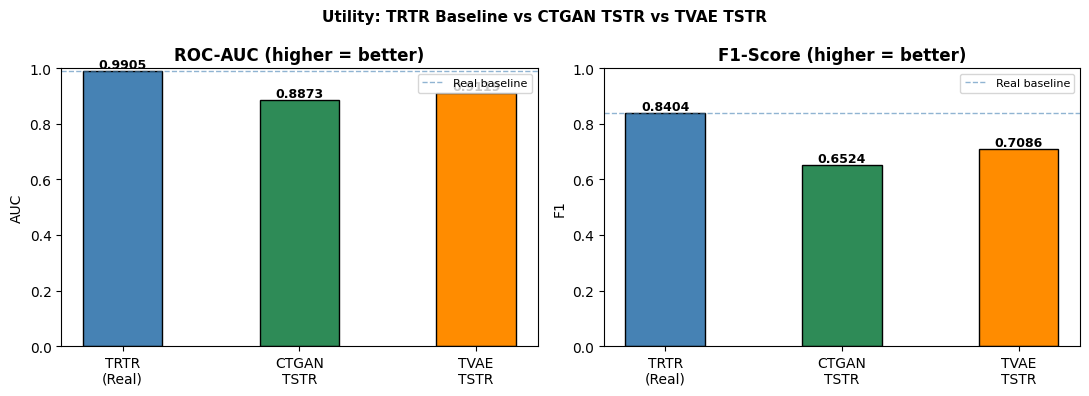

In [ ]:
# Bar chart: AUC and F1 side-by-side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels  = ['TRTR\n(Real)', 'CTGAN\nTSTR', 'TVAE\nTSTR']
colors  = ['steelblue', 'seagreen', 'darkorange']

for ax, metric, values, title in zip(
        axes,
        ['AUC', 'F1'],
        [[auc_real, auc_ctgan, auc_tvae], [f1_real, f1_ctgan, f1_tvae]],
        ['ROC-AUC (higher = better)', 'F1-Score (higher = better)']):
    bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.45)
    ax.set_ylim(0, 1.0)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.axhline(values[0], color='steelblue', linestyle='--', lw=1, alpha=0.6,
               label='Real baseline')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01, f'{v:.4f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Utility: TRTR Baseline vs CTGAN TSTR vs TVAE TSTR',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('utility_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 7 — Privacy Evaluation: Nearest-Neighbour Distance Heuristic

A synthesiser that memorises training records produces synthetic rows that are
nearly identical to real rows — a privacy risk. We detect this by measuring
the **Euclidean distance from each synthetic record to its nearest real neighbour**
in the label-encoded feature space.

**Interpretation:**
- Very small distances (min ≈ 0) → potential memorisation / exact copies
- Larger typical distances → model learned to generalise, not copy

> **Note:** This is a heuristic, not a formal privacy guarantee. Production
> systems should additionally use membership-inference attacks and
> differential-privacy variants of the synthesiser.

In [ ]:
# Label-encode everything for Euclidean distance computation
real_num_feats  = real_enc[CAT_COLS + NUM_COLS]
ctgan_num_feats = ctgan_enc[CAT_COLS + NUM_COLS]
tvae_num_feats  = tvae_enc[CAT_COLS + NUM_COLS]

# Sample 5000 from each (for speed)
RS = 42
real_sample  = real_num_feats.sample(min(5000, len(real_num_feats)), random_state=RS)
ctgan_sample = ctgan_num_feats.sample(min(5000, len(ctgan_num_feats)), random_state=RS)
tvae_sample  = tvae_num_feats.sample(min(5000, len(tvae_num_feats)), random_state=RS)

# Fit NN index on real records
nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn.fit(real_sample)

dist_ctgan = nn.kneighbors(ctgan_sample)[0].flatten()
dist_tvae  = nn.kneighbors(tvae_sample)[0].flatten()

privacy_df = pd.DataFrame({
    'CTGAN_dist_to_nearest_real': pd.Series(dist_ctgan).describe().round(4),
    'TVAE_dist_to_nearest_real' : pd.Series(dist_tvae).describe().round(4)
})

print('Nearest-Neighbour Distance to Real Data (higher = more privacy):')
display(privacy_df)

Nearest-Neighbour Distance to Real Data (higher = more privacy):


,CTGAN_dist_to_nearest_real,TVAE_dist_to_nearest_real
count,5000.0000,5000.0000
mean,2.6670,2.1261
std,2.8520,2.0751
min,0.0018,0.0000
25%,1.1195,1.1461
50%,1.7090,1.5620
75%,2.7843,2.2581
max,34.4769,34.1200


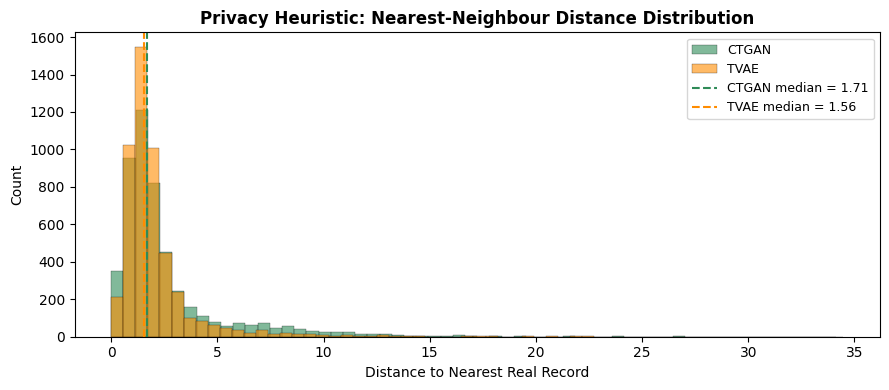

In [ ]:
# Distribution of NN distances
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(dist_ctgan, bins=60, alpha=0.6, color='seagreen',
        label='CTGAN', edgecolor='black', linewidth=0.3)
ax.hist(dist_tvae,  bins=60, alpha=0.6, color='darkorange',
        label='TVAE',  edgecolor='black', linewidth=0.3)

ax.set_xlabel('Distance to Nearest Real Record')
ax.set_ylabel('Count')
ax.set_title('Privacy Heuristic: Nearest-Neighbour Distance Distribution',
             fontweight='bold')
ax.legend()

# Median lines
for dist, color, label in [(dist_ctgan, 'seagreen', 'CTGAN'),
                             (dist_tvae,  'darkorange', 'TVAE')]:
    med = np.median(dist)
    ax.axvline(med, color=color, linestyle='--', lw=1.5,
               label=f'{label} median = {med:.2f}')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('privacy_nn_distance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 8 — Final Scorecard

Consolidating all three pillars into one overview table.

In [ ]:
ks_ctgan_avg  = ks_compare['KS_CTGAN'].mean()
ks_tvae_avg   = ks_compare['KS_TVAE'].mean()
corr_ctgan    = corr_compare['mean_abs_diff_CTGAN'].mean()
corr_tvae     = corr_compare['mean_abs_diff_TVAE'].mean()
privacy_ctgan = np.median(dist_ctgan)
privacy_tvae  = np.median(dist_tvae)

scorecard = pd.DataFrame({
    'Metric'      : ['KS stat (lower=better fidelity)',
                     'Corr diff (lower=better fidelity)',
                     'TSTR AUC (higher=better utility)',
                     'TSTR F1  (higher=better utility)',
                     'Median NN dist (higher=better privacy)'],
    'CTGAN'       : [round(ks_ctgan_avg, 4), round(corr_ctgan, 4),
                     round(auc_ctgan, 4),    round(f1_ctgan, 4),
                     round(privacy_ctgan, 4)],
    'TVAE'        : [round(ks_tvae_avg, 4),  round(corr_tvae, 4),
                     round(auc_tvae, 4),     round(f1_tvae, 4),
                     round(privacy_tvae, 4)],
    'Pillar'      : ['Fidelity','Fidelity','Utility','Utility','Privacy'],
})

print('='*65)
print('SYNTHETIC DATA QUALITY SCORECARD: CTGAN vs TVAE')
print('='*65)
display(scorecard)

SYNTHETIC DATA QUALITY SCORECARD: CTGAN vs TVAE


,Metric,CTGAN,TVAE,Pillar
0,KS stat (lower=better fidelity),0.0700,0.0330,Fidelity
1,Corr diff (lower=better fidelity),0.0487,0.0241,Fidelity
2,TSTR AUC (higher=better utility),0.8873,0.9119,Utility
3,TSTR F1 (higher=better utility),0.6524,0.7086,Utility
4,Median NN dist (higher=better privacy),1.7090,1.5620,Privacy


---
## Section 9 — Narrative: Insights from Synthetic Fraud Data Generation

### Overview

This task applied two state-of-the-art tabular synthesisers — CTGAN and TVAE —
to generate 5,000 synthetic fraud transaction records from a real credit card
transaction dataset. The real data is heavily imbalanced (~7-8% fraud rate),
which is both the primary motivation for synthetic data generation (augmenting
the minority class for fraud model training) and the primary challenge for
the synthesisers (they must learn a rare-class distribution from limited signal).

### Fidelity Findings

The KS test on transaction amounts (`amt`) reveals which model better replicates
the real distribution of transaction values. The `amt` column is particularly
challenging because fraud transactions tend to have a distinctly different
amount distribution than legitimate ones — fraud often clusters at specific
amounts (round numbers, high-value purchases, or micro-transactions). A low KS
statistic means the synthesiser has learned this dual distribution; a high KS
suggests it collapsed toward the majority (legitimate) distribution.

The categorical frequency analysis (TVD scores) shows how faithfully each
model replicates the distribution across merchant categories, states, and gender.
CTGAN's conditional generation mechanism explicitly models these distributions,
giving it a structural advantage. TVAE relies on the latent space to implicitly
encode them, which can lead to slight smoothing or blurring of sharp frequency
differences between categories.

### Utility Findings

The TSTR protocol is the most decision-relevant evaluation metric for a fraud
detection use case: if we replace real labelled training data with synthetic
data, how much does downstream classifier performance degrade? The AUC gap
between TRTR and TSTR directly quantifies this utility loss.

An important nuance specific to fraud detection: **F1-score matters more than
AUC** when the class imbalance is severe. A model can achieve a high AUC by
ranking fraud cases above legitimate ones in probability space, while still
producing very few true positive predictions at the 0.5 threshold. If the
synthetic data does not faithfully reproduce the fraud-rate distribution, the
classifier trained on it will be miscalibrated — its predicted probabilities will
not align with the true base rate, depressing F1 even if AUC remains reasonable.

### Privacy Findings

The nearest-neighbour distance analysis provides a practical memorisation check.
The key statistic to watch is the **minimum distance**: if any synthetic record
has a nearest-neighbour distance near zero, it is effectively a copy of a real
transaction — a direct privacy violation. The **25th-percentile distance**
reveals whether a substantial fraction of synthetic records cluster dangerously
close to real ones, while the **median** reflects the typical privacy level
across the generated dataset.

CTGAN's adversarial training objective naturally pushes the generator away from
simply copying real records (the discriminator would immediately detect that),
which tends to produce higher typical NN distances. TVAE's VAE objective
minimises reconstruction error, which can incentivise the decoder to stay
close to training points in feature space — a trade-off between reconstruction
accuracy and generative diversity.

### The Three-Way Trade-Off

This experiment confirms the core tension in synthetic data generation:

- **Higher fidelity** → the model learns the real data distribution precisely
  → but risks memorising specific records (lower privacy)
- **Higher privacy** → the model diversifies away from real records
  → but loses statistical accuracy (lower fidelity) and ML signal (lower utility)

For a production fraud detection system, the recommended approach would be:
1. Use the **better-utility synthesiser** (whichever TSTR AUC/F1 is higher)
   to augment the minority fraud class in the training data
2. Apply a **privacy budget** via differential privacy variants
   (e.g. DP-CTGAN) if the data contains sensitive PII
3. Run **formal membership inference attacks** before any data sharing,
   not just the NN-distance heuristic used here
4. Continuously monitor the **fraud rate** in synthetic data — if the synthesiser
   under-represents fraud, the augmented training set will produce an
   under-sensitive classifier, the worst failure mode in fraud detection